# Construction of the XGBoost Model (Machine Learning)

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

In [2]:
load_dotenv()
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

try:
    engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")
    query="""
        select
            order_purchase_timestamp::date as order_day,
        sum(price) as revenue
        from
            analytics.fact_orders
        where 
            order_purchase_timestamp is not null
        group by 
            order_day  
        order by 
        order_day
    """

    revenue_df = pd.read_sql(query, con=engine)
    print("---Data set details---")
    print(revenue_df.head(5))

except Exception as e:
    print(f"Detail error: {e}")
finally:
    engine.dispose()

---Data set details---
    order_day  revenue
0  2016-09-04    72.89
1  2016-09-05    59.50
2  2016-09-15   134.97
3  2016-10-02   100.00
4  2016-10-03   463.48


In [3]:
revenue_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   order_day  616 non-null    object 
 1   revenue    616 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.8+ KB


In [4]:
revenue_df["order_day"] = pd.to_datetime(revenue_df["order_day"])
revenue_df.set_index('order_day', inplace=True)

In [5]:
revenue_df.describe()

,revenue
count,616.000000
mean,22064.356656
std,12594.027039
min,10.900000
25%,13018.205000
50%,20511.455000
75%,29591.957500
max,152653.740000


## Feature Engineering

In [11]:
revenue_df["day_of_week"] = revenue_df.index.day_of_week
revenue_df["is_weekend"] = (revenue_df.index.day_of_week >=5).astype(int)
revenue_df["lag_7"] = revenue_df["revenue"].shift(7)
revenue_df["rolling_mean_7"] =(
    revenue_df["revenue"]
    .rolling(7)
    .mean()
)
revenue_df["lag_14"] = revenue_df["revenue"].shift(14)
revenue_df["rolling_mean_14"] =(
    revenue_df["revenue"]
    .rolling(14)
    .mean()
)
revenue_df

,revenue,day_of_week,is_weekend,lag_7,rolling_mean_7,lag_14,rolling_mean_14
order_day,,,,,,,
2016-09-04,72.89,6,1,NaN,NaN,NaN,NaN
2016-09-05,59.50,0,0,NaN,NaN,NaN,NaN
2016-09-15,134.97,3,0,NaN,NaN,NaN,NaN
2016-10-02,100.00,6,1,NaN,NaN,NaN,NaN
2016-10-03,463.48,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2018-08-26,8070.71,6,1,25487.39,18062.041429,31524.21,26574.565714
2018-08-27,5345.91,0,0,34479.50,13900.100000,38613.13,24198.335714
2018-08-28,3673.91,1,0,26323.06,10664.507143,44192.84,21304.126429


In [12]:
revenue_df.dropna(inplace=True)

In [13]:
revenue_df

,revenue,day_of_week,is_weekend,lag_7,rolling_mean_7,lag_14,rolling_mean_14
order_day,,,,,,,
2017-01-06,916.38,4,0,7960.51,3431.948571,72.89,3644.736429
2017-01-07,1351.90,5,1,7228.05,2592.498571,59.50,3737.050714
2017-01-08,709.58,6,1,8441.85,1487.888571,134.97,3778.094286
2017-01-09,673.79,0,0,3336.99,1107.431429,100.00,3819.079286
2017-01-10,1434.87,1,0,3692.57,784.902857,463.48,3888.464286
...,...,...,...,...,...,...,...
2018-08-26,8070.71,6,1,25487.39,18062.041429,31524.21,26574.565714
2018-08-27,5345.91,0,0,34479.50,13900.100000,38613.13,24198.335714
2018-08-28,3673.91,1,0,26323.06,10664.507143,44192.84,21304.126429


## Exploratory analysis of the dataset

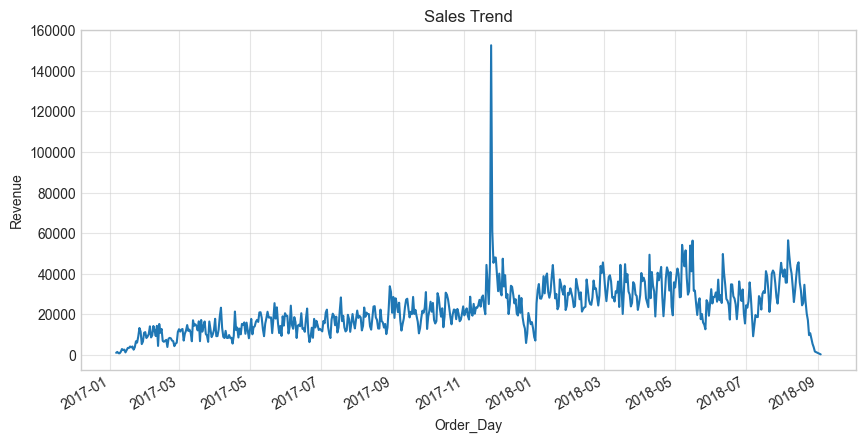

In [34]:
axis= revenue_df["revenue"].plot(figsize=(10,5))
axis.set_xlabel("Order_Day")
axis.set_ylabel("Revenue")
axis.set_title("Sales Trend")
axis.grid(True, alpha=0.5)

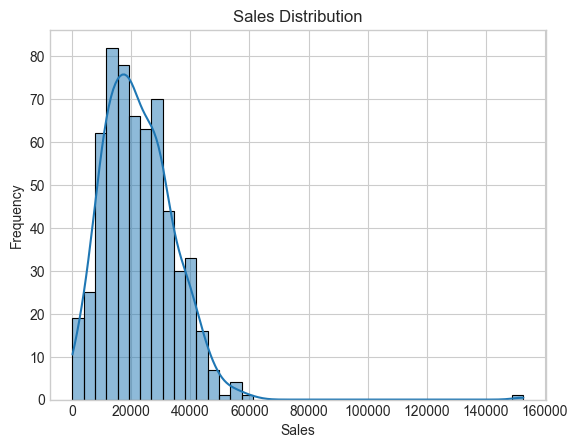

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(revenue_df["revenue"], kde=True,)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

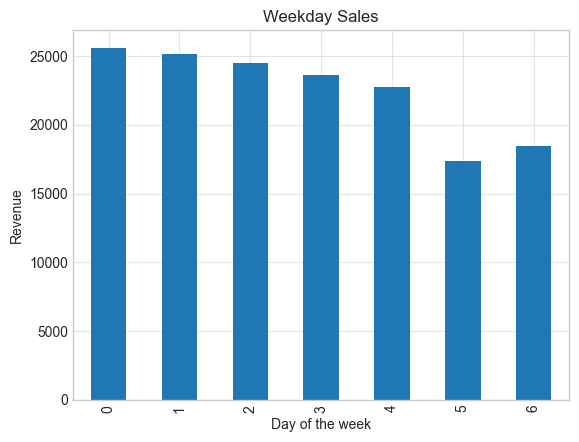

In [37]:
axis= revenue_df.groupby("day_of_week")["revenue"].mean().plot(kind="bar")
axis.set_xlabel("Day of the week")
axis.set_ylabel("Revenue")
axis.set_title("Weekday Sales")
axis.grid(True, alpha=0.5)



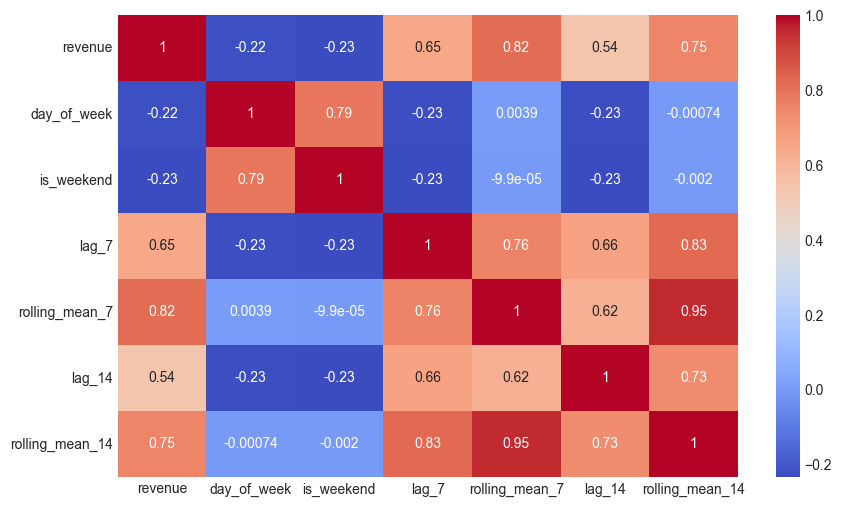

In [42]:
plt.figure(figsize=(10,6))
sns.heatmap(
    revenue_df.corr(),
    annot=True,
    cmap="coolwarm")
plt.show()